# Merging crossover points from laser altimetry and radar

In [28]:
df_xopr

0       POINT (-1561225.314 -427503.747)
1       POINT (-1595929.093 -426660.663)
2       POINT (-1568763.137 -427320.625)
3       POINT (-1609082.649 -426341.114)
4       POINT (-1578534.943 -427083.232)
                      ...               
6852    POINT (-1456797.158 -533397.627)
6858    POINT (-1455865.702 -529078.713)
6860     POINT (-1460009.442 -536806.63)
6875    POINT (-1463535.786 -480769.732)
6917    POINT (-1512330.425 -370536.491)
Name: intersection_geometry, Length: 4057, dtype: geometry

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import cartopy.crs as ccrs

data_dir = "../data/"
df_icesat = gpd.read_parquet(f"{data_dir}x_points_explode.parquet")
df_xopr = gpd.read_parquet(f"{data_dir}intersections.parquet")

df_icesat = df_icesat.to_crs(epsg=3031)
df_xopr_point = df_xopr.intersection_geometry.to_crs(epsg=3031)

# Buffer xopr intersections by xxx m (tune this to your use case)
df_xopr_buffered = df_xopr.copy()
df_xopr_buffered = df_xopr.buffer(50000)

# Now spatial join
df_merged = gpd.sjoin(df_icesat, df_xopr_buffered, how="inner", predicate="within")

print(f"Matched points: {len(df_merged)}")

df_icesat.plot()
plt.show()
df_xopr.plot()
plt.show()
df_merged.plot()
plt.show()

EPSG:3031
EPSG:3031
[-1606895.33932548  -784272.77332667 -1016100.35199563  -157270.14169477]
[-1619488.38902566  -770641.93312486 -1087168.38721184  -136050.82719404]


ValueError: 'right_df' should be GeoDataFrame, got <class 'geopandas.geoseries.GeoSeries'>

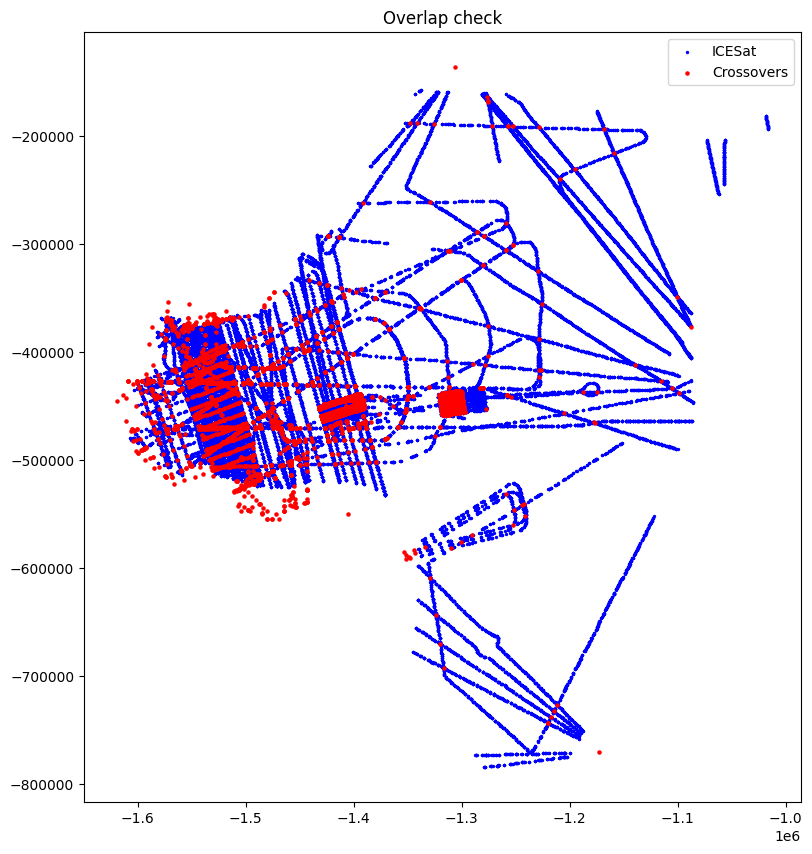

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
df_icesat.plot(ax=ax, color="blue", markersize=2, label="ICESat")
df_xopr.plot(ax=ax, color="red", markersize=5, label="Crossovers")
plt.legend()
plt.title("Overlap check")
plt.savefig("../figs/overlap_check.png")
plt.show()


In [26]:
df_xopr

,id_1,id_2,intersection_geometry,collection_1,collection_2,geom_1,geom_2,opr:date_1,opr:date_2,opr:segment_1,opr:segment_2,opr:frame_1,opr:frame_2,crossing_angle
0,Data_20091018_04_004,Data_20121023_04_037,POINT (-1561225.314 -427503.747),2009_Antarctica_DC8,2012_Antarctica_DC8,"LINESTRING (-1609275.771 -426336.422, -1557851...","LINESTRING (-1564526.603 -419047.947, -1561647...",20091018,20121023,4,4,4,37,66.182940
1,Data_20091018_04_004,Data_20181115_01_001,POINT (-1595929.093 -426660.663),2009_Antarctica_DC8,2018_Antarctica_DC8,"LINESTRING (-1609275.771 -426336.422, -1557851...","LINESTRING (-1598273.96 -424545.697, -1591970....",20091018,20181115,4,1,4,1,40.659492
2,Data_20091018_04_004,Data_20091118_01_005,POINT (-1568763.137 -427320.625),2009_Antarctica_DC8,2009_Antarctica_DC8,"LINESTRING (-1609275.771 -426336.422, -1557851...","LINESTRING (-1558321.581 -423521.034, -1617415...",20091018,20091118,4,1,4,5,21.387926
3,Data_20091018_04_004,Data_20091102_02_014,POINT (-1609082.649 -426341.114),2009_Antarctica_DC8,2009_Antarctica_DC8,"LINESTRING (-1609275.771 -426336.422, -1557851...","LINESTRING (-1581862.611 -439771.72, -1584473....",20091018,20091102,4,2,4,14,33.532411
4,Data_20091018_04_004,Data_20141121_06_014,POINT (-1578534.943 -427083.232),2009_Antarctica_DC8,2014_Antarctica_DC8,"LINESTRING (-1609275.771 -426336.422, -1557851...","LINESTRING (-1562756.275 -417377.483, -1583800...",20091018,20141121,4,6,4,14,32.988864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6852,Data_20181115_01_031,Data_20141103_04_023,POINT (-1456797.158 -533397.627),2018_Antarctica_DC8,2014_Antarctica_DC8,"LINESTRING (-1468164.292 -534367.248, -1467024...","LINESTRING (-1459746.268 -491015.803, -1458410...",20181115,20141103,1,4,31,23,15.460178
6858,Data_20181115_01_031,Data_20091102_02_020,POINT (-1455865.702 -529078.713),2018_Antarctica_DC8,2009_Antarctica_DC8,"LINESTRING (-1468164.292 -534367.248, -1467024...","LINESTRING (-1457926.004 -504868.135, -1457962...",20181115,20091102,1,2,31,20,12.651885
6860,Data_20181115_01_031,Data_20161103_06_024,POINT (-1460009.442 -536806.63),2018_Antarctica_DC8,2016_Antarctica_DC8,"LINESTRING (-1468164.292 -534367.248, -1467024...","LINESTRING (-1457012.328 -519878.391, -1456329...",20181115,20161103,1,6,31,24,63.317774
6875,Data_20181115_01_032,Data_20091102_02_005,POINT (-1463535.786 -480769.732),2018_Antarctica_DC8,2009_Antarctica_DC8,"LINESTRING (-1458379.407 -498614.816, -1458837...","LINESTRING (-1470169.744 -463009.58, -1469003....",20181115,20091102,1,2,32,5,32.762089
